Missing Data:Date       0
Store      0
Product    0
Sales      0
dtype: int64
Cleaned data saved to 'data/cleaned_sales_data.csv'


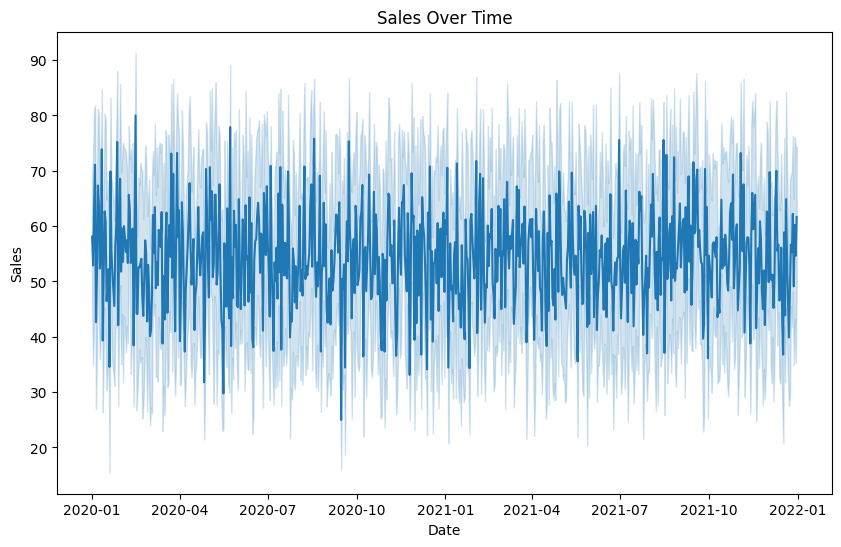

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Step 2: Load the Dataset

# Load the dataset
df = pd.read_csv('../data/sales_data.csv')
df.head()

## Step 3: Data Cleaning

# Check for missing values
missing_data = df.isnull().sum()
print(f"Missing Data:{missing_data}")

# Fill missing sales data with the mean of the column (if any)
df['Sales'] = df['Sales'].fillna(df['Sales'].mean())

# Drop duplicates if there are any
df = df.drop_duplicates()

# Ensure 'Date' is in datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Check the cleaned data
df.head()


## Step 4: Feature Engineering

# Extract Month and DayOfWeek from the Date column
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.weekday

# Create a Holiday flag (mark weekends as holidays)
df['Holiday'] = np.where(df['DayOfWeek'] >= 5, 1, 0)

# Check the data with new features
df.head()


## Step 5: Save the Cleaned Data

# Save the cleaned dataset
df.to_csv('../data/cleaned_sales_data.csv', index=False)
print("Cleaned data saved to 'data/cleaned_sales_data.csv'")


## Step 6: Visualize the Data (Optional)

# Visualizing sales over time
plt.figure(figsize=(10, 6))
sns.lineplot(x='Date', y='Sales', data=df)
plt.title('Sales Over Time')
plt.show()
